In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("smart_infrastructure_risk_dataset.csv")

In [ ]:
print(df.head())
print(df.info())

   complaint_id                                     complaint_text  \
0             1  Pothole on Ondipudur highway not repaired for ...   
1             2  Structural crack near Kovaipudur flyover needs...   
2             3  Storm drain clogged at Thudiyalur junction cre...   
3             4  Electric sparks from transformer near Perur ju...   
4             5  Bridge railings broken near Thudiyalur posing ...   

        category severity                location  complaint_frequency  \
0        pothole     high   Ondipudur, Coimbatore                   40   
1          crack   medium  Kovaipudur, Coimbatore                   30   
2       drainage   medium  Thudiyalur, Coimbatore                   30   
3     electrical     high       Perur, Coimbatore                   41   
4  bridge_damage      low  Thudiyalur, Coimbatore                   11   

   road_age_years rainfall_level traffic_density  damage_size  \
0              23            low            high         7.17   
1   

In [ ]:
label_encoders = {}

for column in df.columns:

    if df[column].dtype == 'object':

        le = LabelEncoder()

        df[column] = le.fit_transform(df[column].astype(str))

        label_encoders[column] = le

In [ ]:
X = df.iloc[:, :-1]

In [ ]:
y = df.iloc[:, -1]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
param_grid = {
    'n_neighbors': range(1, 21)
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 21)})

In [ ]:
best_k = grid.best_params_['n_neighbors']

print("Best K Value:", best_k)

Best K Value: 6


In [ ]:
knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=6)

In [ ]:
accuracy = knn.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.75


In [ ]:
y_pred = knn.predict(X_test)

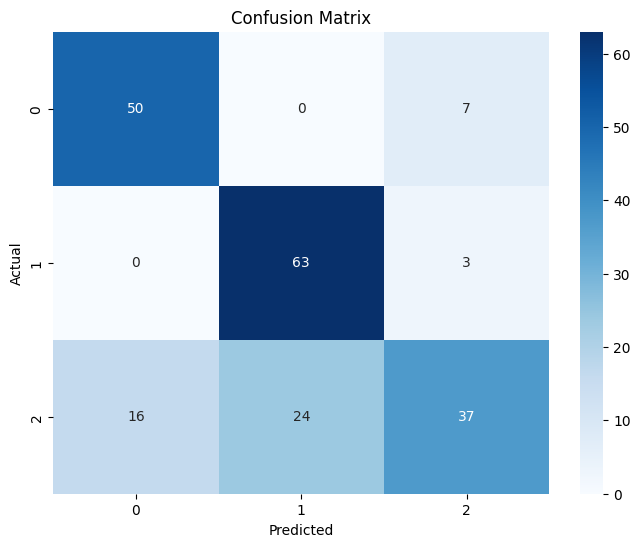

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print("Classification Report:\n")

print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.88      0.81        57
           1       0.72      0.95      0.82        66
           2       0.79      0.48      0.60        77

    accuracy                           0.75       200
   macro avg       0.76      0.77      0.74       200
weighted avg       0.76      0.75      0.73       200

